In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import shap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
 
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]
 
drop_cols = [
    "difficulty",
    "srv_serror_rate", "dst_host_srv_serror_rate",
    "srv_rerror_rate", "dst_host_srv_rerror_rate",
]
categorical_cols = ["protocol_type", "service", "flag"]

In [2]:
train_df = pd.read_csv("../data/KDDTrain.txt", names=columns)
test_df  = pd.read_csv("../data/KDDTest.txt",  names=columns)
 
test_labels = test_df["label"].copy()
 
train_df["binary_label"] = train_df["label"].apply(lambda x: 0 if x == "normal" else 1)
test_df["binary_label"]  = test_df["label"].apply(lambda x: 0 if x == "normal" else 1)
 
train_df = train_df.drop(columns=drop_cols + ["label"])
test_df  = test_df.drop(columns=drop_cols  + ["label"])
 
for col in categorical_cols:
    le = LabelEncoder()
    combined = pd.concat([train_df[col], test_df[col]], axis=0)
    le.fit(combined)
    train_df[col] = le.transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])
 
X_train = train_df.drop(columns=["binary_label"])
y_train = train_df["binary_label"]
X_test  = test_df.drop(columns=["binary_label"])
y_test  = test_df["binary_label"]
 
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos
 
model = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    scale_pos_weight=spw,
    random_state=42, eval_metric="logloss", n_jobs=-1
)
model.fit(X_train, y_train)
 
y_pred = model.predict(X_test)
 
explainer = shap.TreeExplainer(model)

In [3]:
analysis = pd.DataFrame({
    "true_binary": y_test.values,
    "predicted":   y_pred,
    "true_label":  test_labels.values,
    "missed":      ((y_test.values == 1) & (y_pred == 0)).astype(int)
}, index=X_test.index)

In [5]:
gp_idx      = analysis[analysis["true_label"] == "guess_passwd"].index
normal_idx  = analysis[(analysis["true_label"] == "normal") & (analysis["predicted"] == 0)].index
neptune_idx = analysis[(analysis["true_label"] == "neptune") & (analysis["predicted"] == 1)].index

gp_sample      = X_test.loc[gp_idx].sample(min(200, len(gp_idx)), random_state=42)
normal_sample  = X_test.loc[normal_idx].sample(200, random_state=42)
neptune_sample = X_test.loc[neptune_idx].sample(200, random_state=42)

In [6]:
top_features = ["src_bytes", "dst_host_srv_count", "count", "dst_bytes", "dst_host_same_srv_rate"]
 
print("=== FEATURE VALUE COMPARISON ===")
print("(median values across each group)\n")
print(f"{'Feature':<30} {'guess_passwd':>15} {'normal':>15} {'neptune':>15}")
print("-" * 75)
for feat in top_features:
    gp_med  = gp_sample[feat].median()
    nm_med  = normal_sample[feat].median()
    np_med  = neptune_sample[feat].median()
    print(f"{feat:<30} {gp_med:>15.3f} {nm_med:>15.3f} {np_med:>15.3f}")

=== FEATURE VALUE COMPARISON ===
(median values across each group)

Feature                           guess_passwd          normal         neptune
---------------------------------------------------------------------------
src_bytes                               32.000         232.500           0.000
dst_host_srv_count                     196.500         255.000          11.000
count                                    1.000           6.500         199.500
dst_bytes                               93.000         600.500           0.000
dst_host_same_srv_rate                   0.880           1.000           0.040


C:\Users\tuleg\AppData\Local\Temp\ipykernel_13592\1204546025.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_to_plot, labels=["guess_passwd", "normal", "neptune"])
C:\Users\tuleg\AppData\Local\Temp\ipykernel_13592\1204546025.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_to_plot, labels=["guess_passwd", "normal", "neptune"])
C:\Users\tuleg\AppData\Local\Temp\ipykernel_13592\1204546025.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_to_plot, labels=["guess_passwd", "normal", "neptune"])
C:\Users\tuleg\AppData\Local\Temp\ipykernel_13592\12045

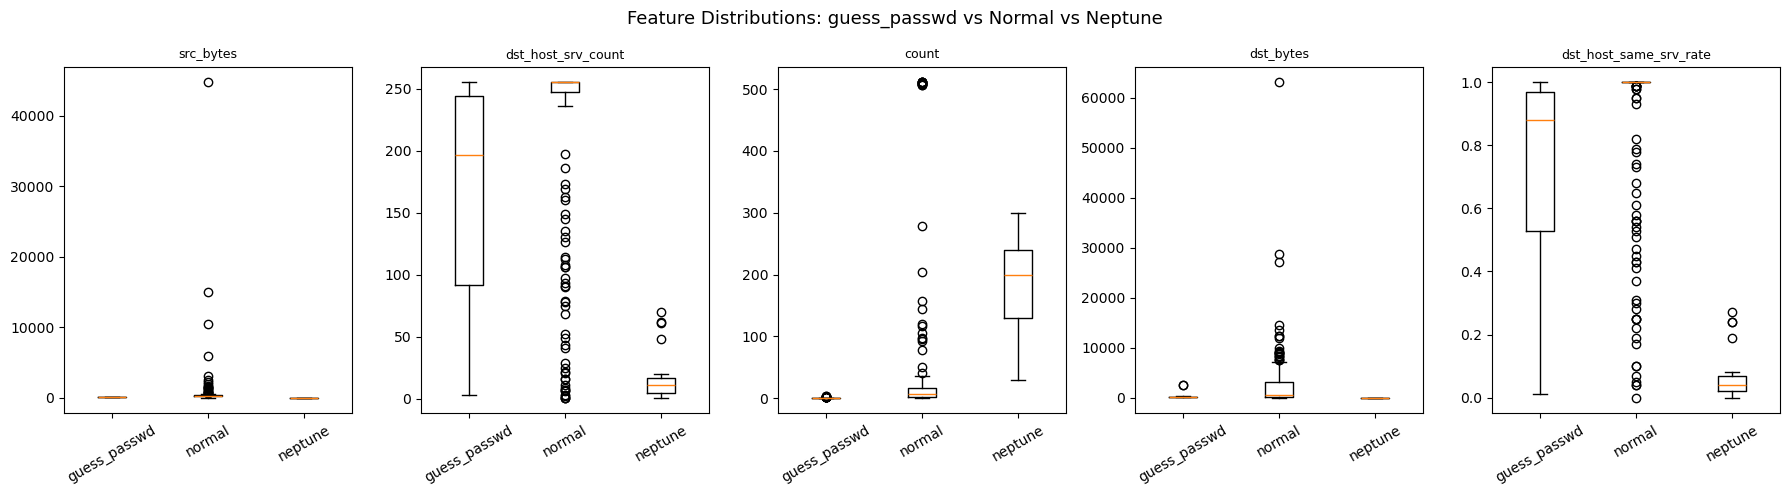

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle("Feature Distributions: guess_passwd vs Normal vs Neptune", fontsize=13)
 
for i, feat in enumerate(top_features):
    data_to_plot = [
        gp_sample[feat].values,
        normal_sample[feat].values,
        neptune_sample[feat].values
    ]
    axes[i].boxplot(data_to_plot, labels=["guess_passwd", "normal", "neptune"])
    axes[i].set_title(feat, fontsize=9)
    axes[i].tick_params(axis='x', rotation=30)
 
plt.tight_layout()

In [9]:
gp_shap      = explainer.shap_values(gp_sample)
neptune_shap = explainer.shap_values(neptune_sample)
normal_shap  = explainer.shap_values(normal_sample)
 
gp_mean_shap      = pd.Series(gp_shap.mean(axis=0),      index=X_train.columns)
neptune_mean_shap = pd.Series(neptune_shap.mean(axis=0), index=X_train.columns)
normal_mean_shap  = pd.Series(normal_shap.mean(axis=0),  index=X_train.columns)
 
print("\n=== MEAN SHAP VALUES PER GROUP (top 10 features by abs value in neptune) ===")
top10 = neptune_mean_shap.abs().sort_values(ascending=False).head(10).index
comparison_shap = pd.DataFrame({
    "guess_passwd": gp_mean_shap[top10],
    "normal":       normal_mean_shap[top10],
    "neptune":      neptune_mean_shap[top10],
})
print(comparison_shap.round(4).to_string())


=== MEAN SHAP VALUES PER GROUP (top 10 features by abs value in neptune) ===
                             guess_passwd  normal  neptune
src_bytes                         -1.6146 -2.4509   4.6415
count                             -0.7739 -0.2595   2.2378
dst_bytes                         -1.0230 -1.1279   0.5317
dst_host_rerror_rate               0.0535 -0.1133   0.4924
service                            0.5785 -0.1818   0.4684
dst_host_srv_count                -1.0643 -1.8812   0.4589
dst_host_serror_rate              -0.1229 -0.0915   0.2762
dst_host_same_src_port_rate       -0.5102 -0.2571  -0.2619
dst_host_count                     0.0900 -0.0199   0.2311
dst_host_same_srv_rate            -0.6927 -0.7230   0.1799


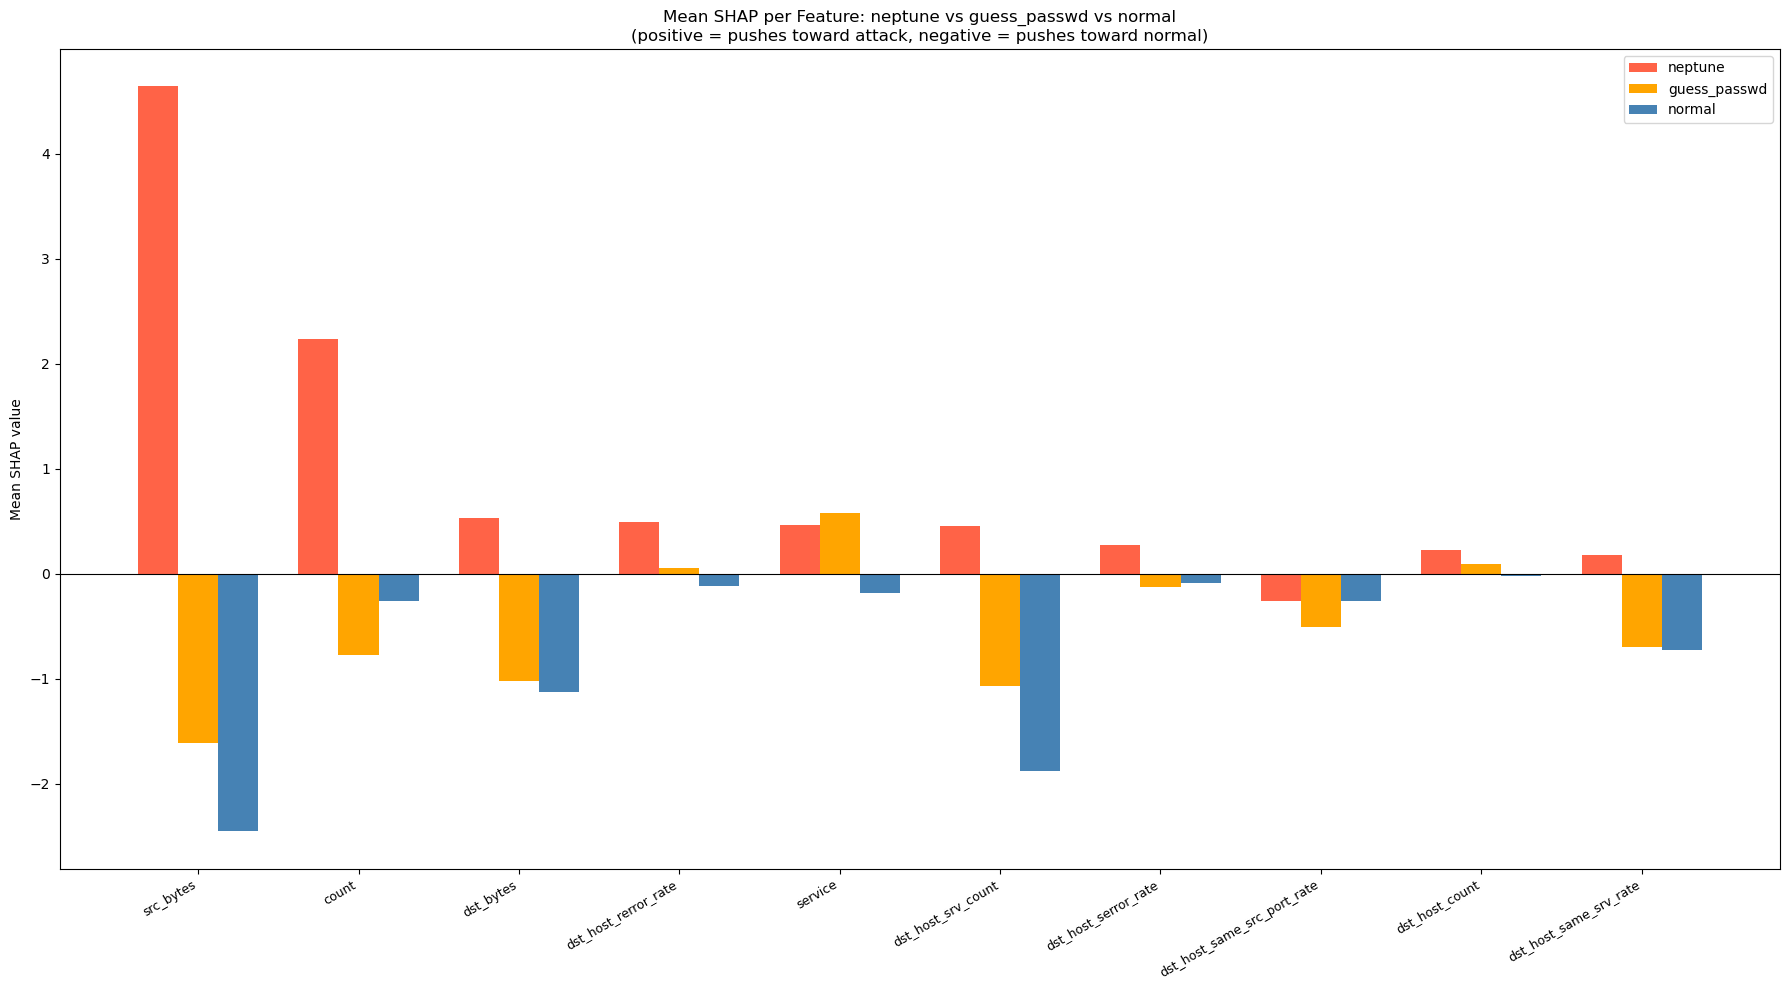

In [12]:
x = np.arange(len(top10))
width = 0.25
 
fig, ax = plt.subplots(figsize=(18, 10))
ax.bar(x - width, comparison_shap["neptune"],      width, label="neptune",      color="tomato")
ax.bar(x,         comparison_shap["guess_passwd"], width, label="guess_passwd", color="orange")
ax.bar(x + width, comparison_shap["normal"],       width, label="normal",       color="steelblue")
 
ax.set_xticks(x)
ax.set_xticklabels(top10, rotation=30, ha="right", fontsize=9)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Mean SHAP value")
ax.set_title("Mean SHAP per Feature: neptune vs guess_passwd vs normal\n"
             "(positive = pushes toward attack, negative = pushes toward normal)")
ax.legend()
plt.tight_layout()

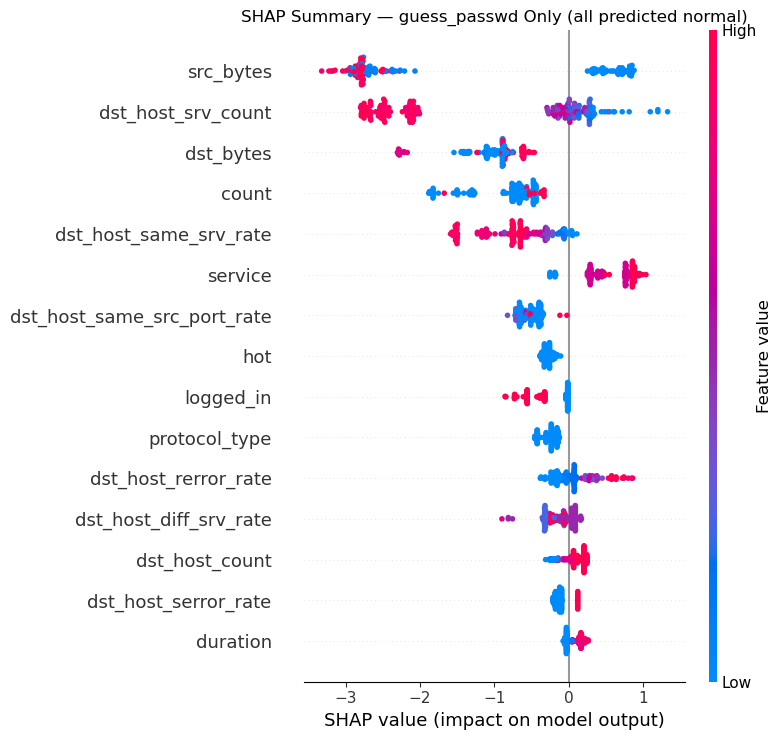

In [14]:
plt.figure()
shap.summary_plot(gp_shap, gp_sample, show=False, max_display=15)
plt.title("SHAP Summary — guess_passwd Only (all predicted normal)")
plt.tight_layout()

In [15]:
print("\n" + "="*60)
print("INDIVIDUAL PREDICTION WALKTHROUGH")
print("="*60)
 
def explain_prediction(label, row_index, X_test, analysis, explainer):
    row      = X_test.loc[[row_index]]
    sv       = explainer.shap_values(row)[0]
    true_lbl = analysis.loc[row_index, "true_label"]
    pred     = analysis.loc[row_index, "predicted"]
 
    print(f"\n[{label}]")
    print(f"True attack type : {true_lbl}")
    print(f"Model predicted  : {'ATTACK' if pred == 1 else 'NORMAL'}")
    print(f"{'Feature':<35} {'Value':>10} {'SHAP':>10} {'Direction'}")
    print("-" * 70)
 
    feature_shap = sorted(
        zip(X_test.columns, row.iloc[0].values, sv),
        key=lambda x: abs(x[2]),
        reverse=True
    )
    for feat, val, shap_val in feature_shap[:10]:
        direction = "→ ATTACK" if shap_val > 0 else "→ NORMAL"
        print(f"{feat:<35} {val:>10.3f} {shap_val:>10.4f}  {direction}")

gp_row = gp_idx[0]
explain_prediction("guess_passwd (MISSED)", gp_row, X_test, analysis, explainer)

neptune_row = neptune_idx[0]
explain_prediction("neptune (CAUGHT)", neptune_row, X_test, analysis, explainer)
 
print("\nAll local SHAP analysis complete.")


INDIVIDUAL PREDICTION WALKTHROUGH

[guess_passwd (MISSED)]
True attack type : guess_passwd
Model predicted  : NORMAL
Feature                                  Value       SHAP Direction
----------------------------------------------------------------------
src_bytes                              129.000    -2.8374  → NORMAL
dst_host_srv_count                     255.000    -2.7531  → NORMAL
service                                 60.000     0.8592  → ATTACK
dst_host_same_srv_rate                   1.000    -0.6479  → NORMAL
dst_bytes                              174.000    -0.6062  → NORMAL
dst_host_same_src_port_rate              0.000    -0.5096  → NORMAL
count                                    1.000    -0.4716  → NORMAL
dst_host_diff_srv_rate                   0.000    -0.3264  → NORMAL
hot                                      0.000    -0.2676  → NORMAL
protocol_type                            1.000    -0.2264  → NORMAL

[neptune (CAUGHT)]
True attack type : neptune
Model predicted 